In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from IPython.display import display

from sklearn import metrics

# versions
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"tensorflow: {tf.__version__}")

I0000 00:00:1781133790.629453   26418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781133790.657231   26418 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


numpy: 2.4.6
pandas: 3.0.3
seaborn: 0.13.2
tensorflow: 2.21.0


In [28]:
data_path = Path("../Finalized_Feature_Sets/model_data_simple.parquet")

model_data_simple = pd.read_parquet(
    data_path,
    engine="pyarrow"
)

model_data_simple.shape

(1700, 31)

# Baseline residual MLP / ResNet-style model for tabular data using TensorFlow/Keras

* isolated imports for clarity

In [29]:
# Define train/test features and outcome
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

random_seed = 321

np.random.seed(random_seed)
tf.random.set_seed(random_seed)

In [ ]:
# One-hot encode categorical predictors

x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print(set(x_train.columns) - set(x_test.columns))  # should be empty set
print(x_train.shape)
print(x_test.shape)

set()
(1274, 46)
(426, 46)


: 

In [6]:
# Standardize predictors

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

## Defining the Model Architecture

In [7]:
# Define a basic residual block

def residual_block(x, units, dropout_rate=0.10):
    shortcut = x

    x = tf.keras.layers.Dense(units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(units, activation=None)(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.Activation("relu")(x)

    return x

In [8]:
# Build basic ResNet-style tabular model

input_dim = x_train_scaled.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))

# Project input to 32 dimensions so residual blocks have matching dimensions
x = tf.keras.layers.Dense(32, activation="relu")(inputs)

# Basic residual blocks
x = residual_block(x, units=32, dropout_rate=0.10)
x = residual_block(x, units=32, dropout_rate=0.10)

# Final classification layer
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

resnet_model = tf.keras.Model(inputs=inputs, outputs=outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

resnet_model.summary()

I0000 00:00:1781133805.671865   26418 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1227 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ dense[0][0],      │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32)        │          0 │ activation[0][0], │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

## Fit the Model

In [9]:
history = resnet_model.fit(
    x_train_scaled,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


I0000 00:00:1781133809.446741   26482 service.cc:153] XLA service 0x7fa51003a490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781133809.446757   26482 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1781133809.471529   26482 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781133809.646793   26482 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1781133809.687697   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:30 3s/step - accuracy: 0.4062 - loss: 0.8324 - pr_auc: 0.3365 - roc_auc: 0.4688

I0000 00:00:1781133811.433846   26482 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1781133811.674199   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.6987 - loss: 0.6157 - pr_auc: 0.2698 - roc_auc: 0.5232 - val_accuracy: 0.8667 - val_loss: 0.4648 - val_pr_auc: 0.1535 - val_roc_auc: 0.4817
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7625 - loss: 0.5223 - pr_auc: 0.4365 - roc_auc: 0.6748 - val_accuracy: 0.8549 - val_loss: 0.4741 - val_pr_auc: 0.1749 - val_roc_auc: 0.4914
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4849 - pr_auc: 0.5336 - roc_auc: 0.7478 - val_accuracy: 0.8078 - val_loss: 0.4989 - val_pr_auc: 0.1730 - val_roc_auc: 0.5016
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.4655 - pr_auc: 0.5845 - roc_auc: 0.7671 - val_accuracy: 0.7843 - val_loss: 0.5052 - val_pr_auc: 0.1793 - val_roc_auc: 0.5160
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.4481 - pr_auc: 0.6330 - roc_auc: 0.7880 - val_accuracy: 0.7765 - val_loss: 0.5250 - val_pr_auc: 0.1733 - val_r

In [10]:
# Predict on test set

y_prob = resnet_model.predict(x_test_scaled).ravel()
y_pred = (y_prob >= 0.50).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


## Metrics and Evaluation

In [11]:
# Evaluate performance

print("Accuracy:", accuracy_score(y_test_array, y_pred))
print("Precision:", precision_score(y_test_array, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_array, y_pred, zero_division=0))
print("F1:", f1_score(y_test_array, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_array, y_prob))
print("PR AUC:", average_precision_score(y_test_array, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_array, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred, zero_division=0))

Accuracy: 0.7136150234741784
Precision: 0.4222222222222222
Recall: 0.35185185185185186
F1: 0.3838383838383838
ROC AUC: 0.6581498951781971
PR AUC: 0.42195552118765806

Confusion Matrix:
[[266  52]
 [ 70  38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       318
           1       0.42      0.35      0.38       108

    accuracy                           0.71       426
   macro avg       0.61      0.59      0.60       426
weighted avg       0.70      0.71      0.70       426



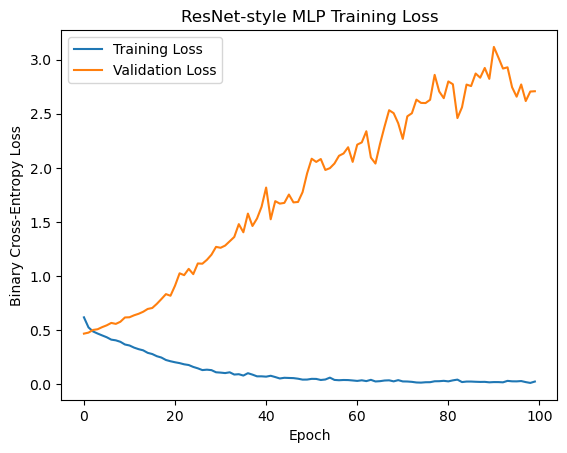

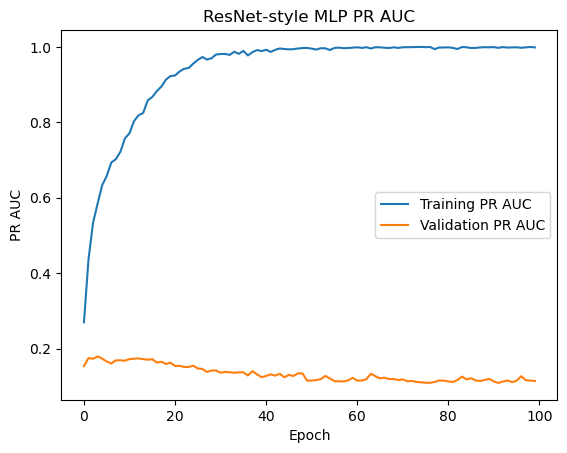

In [12]:
# Plot training curves

import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("ResNet-style MLP Training Loss")
plt.legend()
plt.show()

plt.plot(history.history["pr_auc"], label="Training PR AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR AUC")
plt.xlabel("Epoch")
plt.ylabel("PR AUC")
plt.title("ResNet-style MLP PR AUC")
plt.legend()
plt.show()

## Hyperparameters and Training Setup

__5 key hyperparameters:__

* units: model width
* num_blocks: number of residual blocks
* dropout_rate: regularization strength
* learning_rate: optimizer step size
* l2_strength: weight decay / L2 regularization

In [15]:
import itertools
import time
# import pandas as pd
# import tensorflow as tf

# from sklearn.metrics import average_precision_score, roc_auc_score


def residual_block(x, units, dropout_rate=0.10, l2_strength=0.0):
    shortcut = x

    x = tf.keras.layers.Dense(
        units,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.Dense(
        units,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.Activation("relu")(x)

    return x


def build_resnet_mlp(
    input_dim,
    units=32,
    num_blocks=2,
    dropout_rate=0.10,
    learning_rate=0.001,
    l2_strength=0.0
):
    inputs = tf.keras.Input(shape=(input_dim,))

    x = tf.keras.layers.Dense(
        units,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(inputs)

    for _ in range(num_blocks):
        x = residual_block(
            x,
            units=units,
            dropout_rate=dropout_rate,
            l2_strength=l2_strength
        )

    x = tf.keras.layers.Dense(
        units // 2,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
    )(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [16]:
param_grid = {
    "units": [16, 32, 64],
    "num_blocks": [1, 2],
    "dropout_rate": [0.25, 0.40, 0.55],
    "learning_rate": [0.001, 0.0005],
    "l2_strength": [1e-5, 1e-4, 1e-3]
}

results = []
input_dim = x_train_scaled.shape[1]

max_minutes = 30
start_time = time.time()

for i, (units, num_blocks, dropout_rate, learning_rate, l2_strength) in enumerate(
    itertools.product(
        param_grid["units"],
        param_grid["num_blocks"],
        param_grid["dropout_rate"],
        param_grid["learning_rate"],
        param_grid["l2_strength"]
    ),
    start=1
):

    elapsed_minutes = (time.time() - start_time) / 60
    if elapsed_minutes > max_minutes:
        print(f"Stopping early: reached {max_minutes} minute time budget.")
        break

    tf.keras.backend.clear_session()
    tf.random.set_seed(random_seed)

    model = build_resnet_mlp(
        input_dim=input_dim,
        units=units,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        l2_strength=l2_strength
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        min_delta=0.001,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_scaled,
        y_train_array,
        validation_split=0.20,
        epochs=60,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_pr_auc = max(history.history["val_pr_auc"])
    val_roc_auc = max(history.history["val_roc_auc"])
    min_val_loss = min(history.history["val_loss"])

    results.append({
        "model_number": i,
        "units": units,
        "num_blocks": num_blocks,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "l2_strength": l2_strength,
        "best_val_pr_auc": val_pr_auc,
        "best_val_roc_auc": val_roc_auc,
        "min_val_loss": min_val_loss,
        "epochs_trained": len(history.history["loss"]),
        "elapsed_minutes": elapsed_minutes
    })

    print(
        f"Model {i}: PR AUC={val_pr_auc:.3f}, "
        f"units={units}, blocks={num_blocks}, dropout={dropout_rate}, "
        f"lr={learning_rate}, l2={l2_strength}, epochs={len(history.history['loss'])}"
    )

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["best_val_pr_auc", "min_val_loss"],
    ascending=[False, True]
)

results_df.head(10)

I0000 00:00:1781134134.472054   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_668757__.31
I0000 00:00:1781134135.992809   26479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_668757__.31


Model 1: PR AUC=0.261, units=16, blocks=1, dropout=0.25, lr=0.001, l2=1e-05, epochs=13


I0000 00:00:1781134140.881388   26480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_679623__.31
I0000 00:00:1781134141.784282   26479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_679623__.31


Model 2: PR AUC=0.172, units=16, blocks=1, dropout=0.25, lr=0.001, l2=0.0001, epochs=9


I0000 00:00:1781134145.363319   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_688249__.31
I0000 00:00:1781134146.254490   26482 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_688249__.31


...

I0000 00:00:1781134809.062351   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2094958__.36
I0000 00:00:1781134810.447009   26481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2094958__.36


Model 107: PR AUC=0.306, units=64, blocks=2, dropout=0.55, lr=0.0005, l2=0.0001, epochs=15


I0000 00:00:1781134816.433437   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2108017__.36
I0000 00:00:1781134817.805211   26480 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2108017__.36


Model 108: PR AUC=0.247, units=64, blocks=2, dropout=0.55, lr=0.0005, l2=0.001, epochs=23


,model_number,units,num_blocks,dropout_rate,learning_rate,l2_strength,best_val_pr_auc,best_val_roc_auc,min_val_loss,epochs_trained,elapsed_minutes
83,84,64,1,0.40,0.0005,0.00100,0.419489,0.743203,0.597414,9,8.607830
62,63,32,2,0.40,0.0010,0.00100,0.371911,0.663887,0.575885,11,6.288480
93,94,64,2,0.25,0.0005,0.00001,0.357496,0.660244,0.487752,11,9.632217
84,85,64,1,0.55,0.0010,0.00001,0.345568,0.643147,0.450289,8,8.702665
65,66,32,2,0.40,0.0005,0.00100,0.320264,0.638943,0.593551,14,6.633475
27,28,16,2,0.40,0.0005,0.00001,0.319589,0.595992,0.435711,35,2.670244
34,35,16,2,0.55,0.0005,0.00010,0.319559,0.634109,0.480492,34,3.401392
54,55,32,2,0.25,0.0010,0.00001,0.313509,0.674818,0.450529,15,5.420927
87,88,64,1,0.55,0.0005,0.00001,0.312646,0.629134,0.441563,11,8.987209
81,82,64,1,0.40,0.0005,0.00001,0.308763,0.654638,0.430424,9,8.380747


In [17]:
results_df = pd.DataFrame(results)

top10_pr_auc = results_df.sort_values(
    by="best_val_pr_auc",
    ascending=False
).head(10)

top10_loss = results_df.sort_values(
    by="min_val_loss",
    ascending=True
).head(10)

print("Top 10 models by validation PR AUC:")
display(top10_pr_auc)

print("Top 10 models by validation loss:")
display(top10_loss)

Top 10 models by validation PR AUC:


,model_number,units,num_blocks,dropout_rate,learning_rate,l2_strength,best_val_pr_auc,best_val_roc_auc,min_val_loss,epochs_trained,elapsed_minutes
83,84,64,1,0.40,0.0005,0.00100,0.419489,0.743203,0.597414,9,8.607830
62,63,32,2,0.40,0.0010,0.00100,0.371911,0.663887,0.575885,11,6.288480
93,94,64,2,0.25,0.0005,0.00001,0.357496,0.660244,0.487752,11,9.632217
84,85,64,1,0.55,0.0010,0.00001,0.345568,0.643147,0.450289,8,8.702665
65,66,32,2,0.40,0.0005,0.00100,0.320264,0.638943,0.593551,14,6.633475
27,28,16,2,0.40,0.0005,0.00001,0.319589,0.595992,0.435711,35,2.670244
34,35,16,2,0.55,0.0005,0.00010,0.319559,0.634109,0.480492,34,3.401392
54,55,32,2,0.25,0.0010,0.00001,0.313509,0.674818,0.450529,15,5.420927
87,88,64,1,0.55,0.0005,0.00001,0.312646,0.629134,0.441563,11,8.987209
81,82,64,1,0.40,0.0005,0.00001,0.308763,0.654638,0.430424,9,8.380747


Top 10 models by validation loss:


,model_number,units,num_blocks,dropout_rate,learning_rate,l2_strength,best_val_pr_auc,best_val_roc_auc,min_val_loss,epochs_trained,elapsed_minutes
39,40,32,1,0.25,0.0005,0.00001,0.249130,0.626121,0.430366,18,3.918856
81,82,64,1,0.40,0.0005,0.00001,0.308763,0.654638,0.430424,9,8.380747
72,73,64,1,0.25,0.0010,0.00001,0.278116,0.576584,0.432074,8,7.422047
46,47,32,1,0.40,0.0005,0.00010,0.291327,0.665709,0.432902,18,4.598876
27,28,16,2,0.40,0.0005,0.00001,0.319589,0.595992,0.435711,35,2.670244
60,61,32,2,0.40,0.0010,0.00001,0.240090,0.604680,0.435857,14,6.068867
87,88,64,1,0.55,0.0005,0.00001,0.312646,0.629134,0.441563,11,8.987209
21,22,16,2,0.25,0.0005,0.00001,0.225630,0.591017,0.442503,18,2.064041
30,31,16,2,0.55,0.0010,0.00001,0.226771,0.611267,0.443002,8,2.999113
3,4,16,1,0.25,0.0005,0.00001,0.265028,0.610986,0.443518,17,0.263625


Ranking for models is done primarily by validation PR AUC, not validation loss, because the outcome is imbalanced and the clinical goal is identifying CHF cases. Validation loss is still useful as a secondary check for overfitting/calibration.

In [ ]:
results_df.sort_values(
    by=["best_val_pr_auc", "min_val_loss"],
    ascending=[False, True]
).head(10)

In [18]:
best_params = results_df.iloc[0].to_dict()
best_params

{'model_number': 1.0,
 'units': 16.0,
 'num_blocks': 1.0,
 'dropout_rate': 0.25,
 'learning_rate': 0.001,
 'l2_strength': 1e-05,
 'best_val_pr_auc': 0.2609635889530182,
 'best_val_roc_auc': 0.6571608781814575,
 'min_val_loss': 0.47634485363960266,
 'epochs_trained': 13.0,
 'elapsed_minutes': 3.3020973205566405e-06}

In [19]:
tf.keras.backend.clear_session()
tf.random.set_seed(random_seed)

best_model = build_resnet_mlp(
    input_dim=input_dim,
    units=int(best_params["units"]),
    num_blocks=int(best_params["num_blocks"]),
    dropout_rate=best_params["dropout_rate"],
    learning_rate=best_params["learning_rate"],
    l2_strength=best_params["l2_strength"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

history = best_model.fit(
    x_train_scaled,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1781135204.016050   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2124760__.31


 1/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5312 - loss: 0.7270 - pr_auc: 0.4276 - roc_auc: 0.5443

I0000 00:00:1781135204.971396   26478 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2124760__.31


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6634 - loss: 0.6494 - pr_auc: 0.2810 - roc_auc: 0.4919 - val_accuracy: 0.7412 - val_loss: 0.5760 - val_pr_auc: 0.1268 - val_roc_auc: 0.5275
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7556 - loss: 0.5845 - pr_auc: 0.3357 - roc_auc: 0.5454 - val_accuracy: 0.7882 - val_loss: 0.5314 - val_pr_auc: 0.1335 - val_roc_auc: 0.5445
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7635 - loss: 0.5526 - pr_auc: 0.3969 - roc_auc: 0.6015 - val_accuracy: 0.7922 - val_loss: 0.5181 - val_pr_auc: 0.1423 - val_roc_auc: 0.5575
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7772 - loss: 0.5206 - pr_auc: 0.4752 - roc_auc: 0.6650 - val_accuracy: 0.7804 - val_loss: 0.5204 - val_pr_auc: 0.1516 - val_roc_auc: 0.5769
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7870 - loss: 0.5107 - pr_auc: 0.4984 - roc_auc: 0.6825 - val_accuracy: 0.7725 - val_loss: 0.5269 - val_pr_auc: 0.1573 - val_ro

In [20]:
y_prob = best_model.predict(x_test_scaled).ravel()
y_pred = (y_prob >= 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test_array, y_pred))
print("Precision:", precision_score(y_test_array, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_array, y_pred, zero_division=0))
print("F1:", f1_score(y_test_array, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_array, y_prob))
print("PR AUC:", average_precision_score(y_test_array, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_array, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred, zero_division=0))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Accuracy: 0.7605633802816901
Precision: 0.5517241379310345
Recall: 0.2962962962962963
F1: 0.3855421686746988
ROC AUC: 0.6674237130211973
PR AUC: 0.5062670747120641

Confusion Matrix:
[[292  26]
 [ 76  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       318
           1       0.55      0.30      0.39       108

    accuracy                           0.76       426
   macro avg       0.67      0.61      0.62       426
weighted avg       0.73      0.76      0.73       426



In [25]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        752 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        272 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16)        │          0 │ dense[0][0],      │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        136 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │          9 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,325 (16.90 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,884 (11.27 KB)

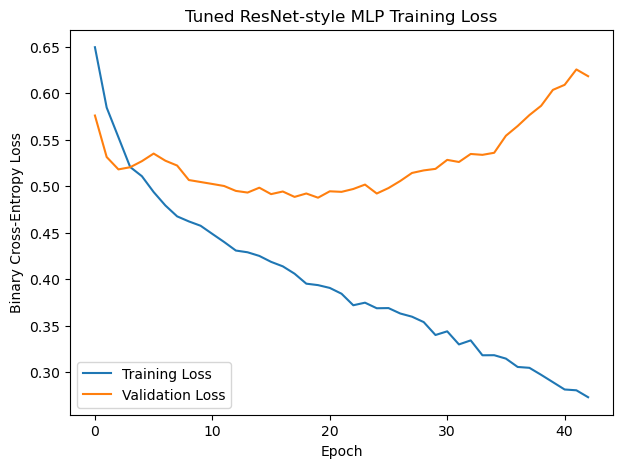

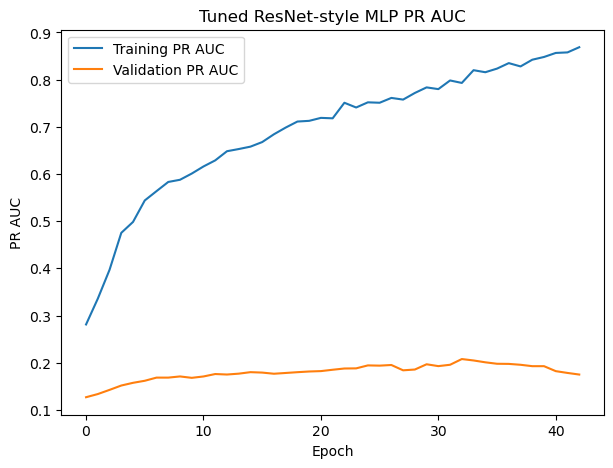

In [21]:
# Plot training curves for tuned ResNet-style MLP

import matplotlib.pyplot as plt

# -----------------------------
# Loss curve
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Tuned ResNet-style MLP Training Loss")
plt.legend()
plt.show()


# -----------------------------
# PR AUC curve
# -----------------------------

plt.figure(figsize=(7, 5))
plt.plot(history.history["pr_auc"], label="Training PR AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR AUC")
plt.xlabel("Epoch")
plt.ylabel("PR AUC")
plt.title("Tuned ResNet-style MLP PR AUC")
plt.legend()
plt.show()

In [22]:
pd.DataFrame({
    "epoch": range(len(history.history["val_loss"])),
    "val_loss": history.history["val_loss"],
    "val_pr_auc": history.history["val_pr_auc"]
})

,epoch,val_loss,val_pr_auc
0,0,0.575975,0.126782
1,1,0.531353,0.133502
2,2,0.518068,0.142349
3,3,0.520385,0.151571
4,4,0.526919,0.157316
5,5,0.535076,0.161663
6,6,0.527392,0.168356
7,7,0.522192,0.168334
8,8,0.506611,0.170844
9,9,0.504496,0.167870


In [23]:
max(history.history["val_pr_auc"])

0.20769456028938293

In [24]:
np.argmax(history.history["val_pr_auc"])

np.int64(32)

In [27]:
print(x_train.columns.tolist())

['AGE', 'SEX', 'INF_ANAM', 'IBS_POST', 'GB', 'endocr_01', 'S_AD_ORIT', 'D_AD_ORIT', 'O_L_POST', 'MP_TP_POST', 'NA_BLOOD', 'K_BLOOD', 'L_BLOOD', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'ritm_ecg_p_01', 'any_pulmonary_disease', 'any_arrhythmia', 'any_conduction_block', 'ROE_log', 'ALT_BLOOD_log', 'AST_BLOOD_log', 'ZSN_A_recode_mild', 'ZSN_A_recode_missing', 'ZSN_A_recode_moderate_severe', 'ZSN_A_recode_none', 'time_bin_early', 'time_bin_intermediate', 'time_bin_late', 'time_bin_missing', 'angina_timing_intermediate', 'angina_timing_missing', 'angina_timing_never', 'angina_timing_recent', 'angina_timing_remote', 'angina_severity_missing', 'angina_severity_moderate', 'angina_severity_none', 'angina_severity_other', 'htn_duration_long', 'htn_duration_medium', 'htn_duration_missing', 'htn_duration_none', 'htn_duration_short']
